# Total Bars

=== Building Rust binary in release mode ===
Cargo build completed successfully.

Running for table_type=heap with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--op-ratio', '0.005', '--txn-count', '40', '--scan-count', '6', '--warehouse-count', '5', '--table-type', 'heap']
-----------------------------------------------------------------------
Hash table type: Heap
Rng seed: 232323223
-----------------------------------------------------------------------

Update ratio: 0.005
Analytical ratio: 0.4
Number of transactions (max Timestamp value): 40
Number of each scan transactions: 6

-----------------------------------------------------------------------

txs:
idx:   0, tx_id:   0, tx_ts:   0, tx_type:   InitLoad, Insert count: 150000
idx:   1, tx_id:   1, tx_ts:   1, tx_type:     MarkTs, Mark Ts: 1
idx:   2, tx_id:   2, tx_ts:   2, tx_type:     Update, Update count: 750
idx:   3, tx_id:   3, tx_ts:   3, tx_type:     Update, Update count: 750
idx:   4, tx_id:   4, t

,idx,tx_id,tx_type,repair_type,table_type,duration_ms,count,read_ts,from_ts,to_ts
0,0,0,InitLoad,No Repair,heap,32.919385,150000.0,NaN,NaN,NaN
1,0,0,InitLoad,Read Repair,heap,32.945277,150000.0,NaN,NaN,NaN
2,0,0,InitLoad,Write Repair,heap,33.363059,150000.0,NaN,NaN,NaN
3,1,1,MarkTs,No Repair,heap,0.000000,NaN,1.0,NaN,NaN
4,1,1,MarkTs,Read Repair,heap,0.000000,NaN,1.0,NaN,NaN
5,1,1,MarkTs,Write Repair,heap,0.000000,NaN,1.0,NaN,NaN
6,2,2,Update,No Repair,heap,0.297656,750.0,NaN,NaN,NaN
7,2,2,Update,Read Repair,heap,0.295155,750.0,NaN,NaN,NaN
8,2,2,Update,Write Repair,heap,2.767637,750.0,NaN,NaN,NaN
9,3,3,Update,No Repair,heap,0.171324,750.0,NaN,NaN,NaN


duration_max: 66.84689


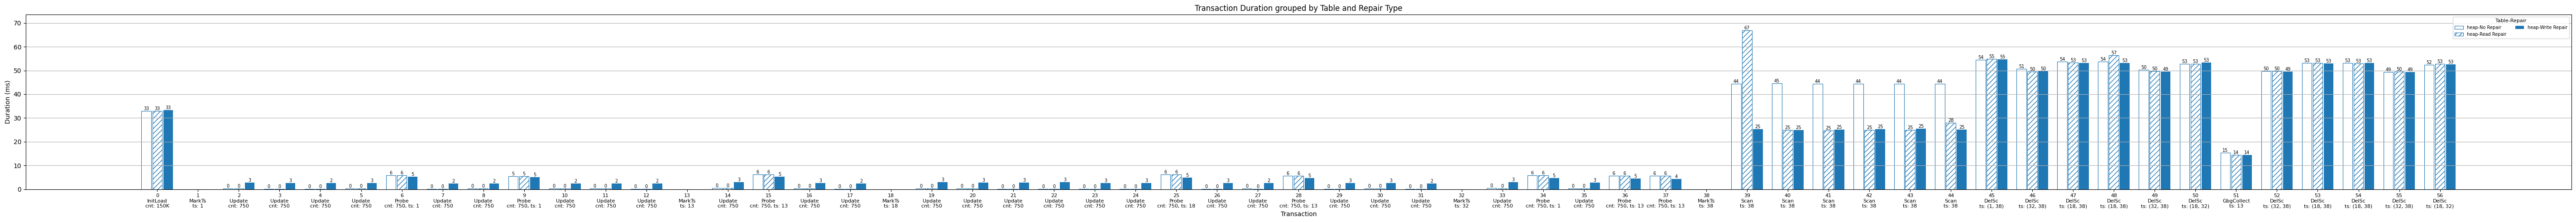

In [ ]:
import subprocess
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re

# ----------------------------------------
# Build the Rust binary
# ----------------------------------------
print("=== Building Rust binary in release mode ===")
build_cmd = ["cargo", "build", "--release", "--bin", "htap_wkld"]
result = subprocess.run(build_cmd, capture_output=True, text=True)
if result.returncode != 0:
    print("[ERROR] cargo build failed.\n", result.stderr)
    raise SystemExit(1)
print("Cargo build completed successfully.\n")


BASE_ARGS = [
    "--update-ratio", "0.005",  # update ratio, % of base table
    "--probe-ratio", "0.005",
    "--txn-count", "40",  
    "--scan-count", "6",  # delta scan count
    "--warehouse-count", "5" # linear to base table size
]
REPEAT=1
BIN = Path("../../../target/release/htap_wkld")
TABLE_TYPES = [ "naive", "heap", "par", "chain"]

def prepare_bar_style(repair_type, table_type, color_map, repair_hatches):
    if repair_type == "Write Repair":
        return {
            'facecolor': color_map[table_type],
            'edgecolor': color_map[table_type],
            'hatch': '',
            'linewidth': 0
        }
    else:
        return {
            'facecolor': 'white',
            'edgecolor': color_map[table_type],
            'hatch': repair_hatches.get(repair_type, ''),
            'linewidth': 0.8
        }
def draw_bar_labels(ax, x_positions, heights, font_size=7):
    for x, y in zip(x_positions, heights):
        if y > 0:  
            ax.text(
                x, 
                y, 
                f"{y:.0f}", 
                ha='center', 
                va='bottom', 
                fontsize=font_size
            )
from bench_script_functions import prepare_plot_data
def plot_all(df):
    color_map, repair_hatches, repair_types, table_types, unique_idx, x_labels, _ = prepare_plot_data(df)

    fig, ax = plt.subplots(figsize=(max(8, len(unique_idx) * 1.0), 5))

    groups = []
    for table_type in table_types:
        if table_type in ["chain", "naive"]:
            groups.append((table_type, "Write Repair"))
        else:
            for repair_type in repair_types:
                groups.append((table_type, repair_type))

    num_bars_per_group = len(groups)
    group_width = 0.8
    bar_width = group_width / num_bars_per_group

    idx_to_pos = {idx: pos for pos, idx in enumerate(unique_idx)}

    duration_max = 0.0
    for i, (table_type, repair_type) in enumerate(groups):
        if table_type in ["chain", "naive"] and repair_type != "Write Repair":
            continue

        df_group = df[(df['table_type'] == table_type) & (df['repair_type'] == repair_type)]

        x_positions = []
        durations = []

        for idx in unique_idx:
            x_pos = idx_to_pos[idx] + (i - num_bars_per_group/2) * bar_width + bar_width/2
            df_row = df_group[df_group['idx'] == idx]
            duration = df_row['duration_ms'].values[0] if not df_row.empty else 0
            x_positions.append(x_pos)
            durations.append(duration)

        style = prepare_bar_style(repair_type, table_type, color_map, repair_hatches)

        ax.bar(
            x_positions,
            durations,
            width=bar_width * 0.9,
            label=f"{table_type}-{repair_type}",
            **style
        )
        duration_max = max(duration_max, max(durations))
        draw_bar_labels(ax, x_positions, durations)

  
    print(f"duration_max: {duration_max}")
    max_y = duration_max * 1.1
    ax.set_ylim(0, max_y)

    ax.set_xticks(range(len(unique_idx)))
    ax.set_xticklabels(x_labels, rotation=0, fontsize=8, ha='center')

    ax.set_xlabel('Transaction')
    ax.set_ylabel('Duration (ms)')
    ax.set_title(f'Transaction Duration grouped by Table and Repair Type')

    plt.grid(True, axis='y')

    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), title="Table-Repair", fontsize=7, title_fontsize=8, ncol=2)

    plt.tight_layout()
    plt.show()
from bench_script_functions import run_and_collect
df = run_and_collect(BIN, TABLE_TYPES, BASE_ARGS, REPEAT)
# Display the resulting DataFrame
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
display(df)
plot_all(df)



# Space Statistics

=== Building Rust binary in release mode ===
Cargo build completed successfully.

Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--op-ratio', '0.01', '--txn-count', '25', '--scan-count', '6', '--warehouse-count', '40', '--space-stat', 'on', '--table-type', 'naive']
-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 232323223
-----------------------------------------------------------------------

Update ratio: 0.01
Analytical ratio: 0.4
Number of transactions (max Timestamp value): 25
Number of each scan transactions: 6

-----------------------------------------------------------------------

txs:
idx:   0, tx_id:   0, tx_ts:   0, tx_type:   InitLoad, Insert count: 1200000
idx:   1, tx_id:   1, tx_ts:   1, tx_type:     MarkTs, Mark Ts: 1
idx:   2, tx_id:   2, tx_ts:   2, tx_type:     Update, Update count: 12000
idx:   3, tx_id:   3, tx_ts:   3, tx_type:     Update, Update count: 

,table_type,repair_type,total_space,all_versions_space,valid_space
0,naive,No Repair,3705667584,3436800000,859200000
1,heap,No Repair,1093402624,996672000,859200000
2,par,No Repair,1176764416,996672000,859200000
3,chain,No Repair,1109917696,996672000,859200000


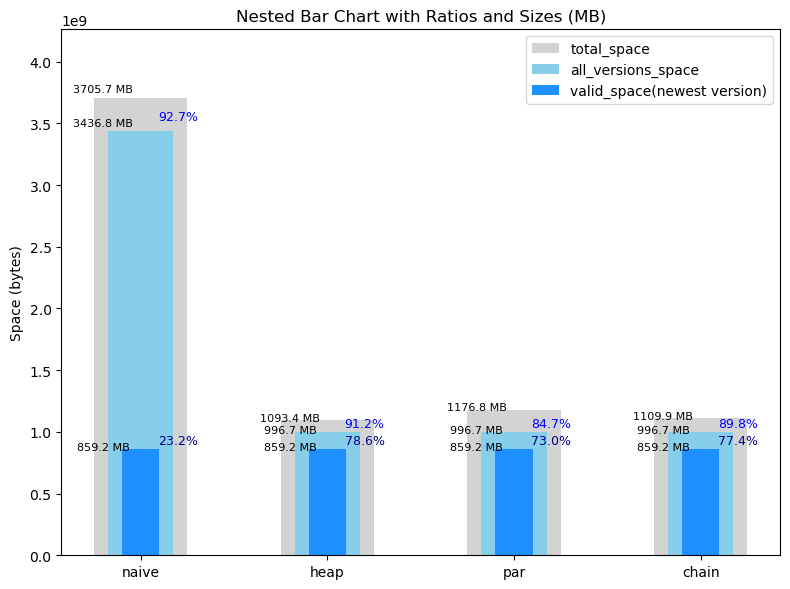

In [ ]:
import subprocess
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re

# ----------------------------------------
# Build the Rust binary
# ----------------------------------------
print("=== Building Rust binary in release mode ===")
build_cmd = ["cargo", "build", "--release", "--bin", "htap_wkld"]
result = subprocess.run(build_cmd, capture_output=True, text=True)
if result.returncode != 0:
    print("[ERROR] cargo build failed.\n", result.stderr)
    raise SystemExit(1)
print("Cargo build completed successfully.\n")


BASE_ARGS = [
    "--update-ratio", "0.01",  # update ratio, % of base table
    "--probe-ratio", "0.005",
    "--txn-count", "25",  
    "--scan-count", "6",  # delta scan count
    "--warehouse-count", "40" # linear to base table size
]
REPEAT=1
BIN = Path("../../../target/release/htap_wkld")
TABLE_TYPES = [ "naive", "heap", "par", "chain"]

from bench_script_functions import run_and_collect_space
new_args = BASE_ARGS + ["--space-stat", "on"]

df = run_and_collect_space(BIN, TABLE_TYPES, new_args, REPEAT)
# Display the resulting DataFrame
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
display(df)

def plot_nested_space(df):
    for col in ["total_space", "all_versions_space", "valid_space"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["all_versions_ratio"] = df["all_versions_space"] / df["total_space"]
    df["valid_ratio"] = df["valid_space"] / df["total_space"]

    fig, ax = plt.subplots(figsize=(8,6))
    bar_width = 0.5

    ax.bar(df["table_type"], df["total_space"], 
           color="lightgray", width=bar_width, label="total_space")
    ax.bar(df["table_type"], df["all_versions_space"], 
           color="skyblue", width=bar_width*0.7, label="all_versions_space")
    ax.bar(df["table_type"], df["valid_space"], 
           color="dodgerblue", width=bar_width*0.4, label="valid_space(newest version)")

    for i, row in df.iterrows():
        total_mb = row["total_space"] / 1e6
        all_versions_mb = row["all_versions_space"] / 1e6
        valid_mb = row["valid_space"] / 1e6

        ax.text(i - 0.2, row["total_space"] * 1.02, f"{total_mb:.1f} MB", 
                ha="center", va="center", fontsize=8, color="black")
        ax.text(i - 0.2, row["all_versions_space"] * 1.02, f"{all_versions_mb:.1f} MB", 
                ha="center", va="center", fontsize=8, color="black")
        ax.text(i - 0.2, row["valid_space"] * 1.02, f"{valid_mb:.1f} MB", 
                ha="center", va="center", fontsize=8, color="black")

        ax.text(i + 0.2, row["all_versions_space"] * 1.02,
                f"{row['all_versions_ratio']:.1%}", 
                ha="center", va="bottom", fontsize=9, color="blue")
        ax.text(i + 0.2, row["valid_space"] * 1.02,
                f"{row['valid_ratio']:.1%}", 
                ha="center", va="bottom", fontsize=9, color="darkblue")

    ax.set_ylabel("Space (bytes)")
    max_value = df[["total_space", "all_versions_space", "valid_space"]].values.max()
    ax.set_ylim(0, max_value * 1.15)
    ax.set_title("Nested Bar Chart with Ratios and Sizes (MB)")
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_nested_space(df)



# Stacked Bar Chart -- analytical

=== Building Rust binary in release mode ===
Cargo build completed successfully.

Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--op-ratio', '0.005', '--txn-count', '40', '--warehouse-count', '4', '--analytical-ratio', '0.9', '--scan-count', '9', '--table-type', 'naive']
-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 232323223
-----------------------------------------------------------------------

Update ratio: 0.005
Analytical ratio: 0.9
Number of transactions (max Timestamp value): 40
Number of each scan transactions: 9

-----------------------------------------------------------------------

txs:
idx:   0, tx_id:   0, tx_ts:   0, tx_type:   InitLoad, Insert count: 120000
idx:   1, tx_id:   1, tx_ts:   1, tx_type:     MarkTs, Mark Ts: 1
idx:   2, tx_id:   2, tx_ts:   2, tx_type:      Probe, Probe count: 600 at read_ts: 1
idx:   3, tx_id:   3, tx_ts:   3, tx_type:      Pro

-----------------------------------------------------------------------
Hash table type: Chain
Rng seed: 232323223
-----------------------------------------------------------------------

Update ratio: 0.005
Analytical ratio: 0.9
Number of transactions (max Timestamp value): 40
Number of each scan transactions: 9

-----------------------------------------------------------------------

txs:
idx:   0, tx_id:   0, tx_ts:   0, tx_type:   InitLoad, Insert count: 120000
idx:   1, tx_id:   1, tx_ts:   1, tx_type:     MarkTs, Mark Ts: 1
idx:   2, tx_id:   2, tx_ts:   2, tx_type:      Probe, Probe count: 600 at read_ts: 1
idx:   3, tx_id:   3, tx_ts:   3, tx_type:      Probe, Probe count: 600 at read_ts: 1
idx:   4, tx_id:   4, tx_ts:   4, tx_type:      Probe, Probe count: 600 at read_ts: 1
idx:   5, tx_id:   5, tx_ts:   5, tx_type:      Probe, Probe count: 600 at read_ts: 1
idx:   6, tx_id:   6, tx_ts:   6, tx_type:      Probe, Probe count: 600 at read_ts: 1
idx:   7, tx_id:   7, tx_ts:   7, 

,table_type,repair_type,tx_type,duration_ms
0,chain,Write Repair,DelSc,1397.824642
1,chain,Write Repair,GbgCollect,0.057656
2,chain,Write Repair,InitLoad,81.200481
3,chain,Write Repair,MarkTs,0.000000
4,chain,Write Repair,Probe,119.013881
5,chain,Write Repair,Scan,488.054870
6,chain,Write Repair,Update,29.059328
7,heap,No Repair,DelSc,1498.997222
8,heap,No Repair,GbgCollect,31.066733
9,heap,No Repair,InitLoad,80.699779


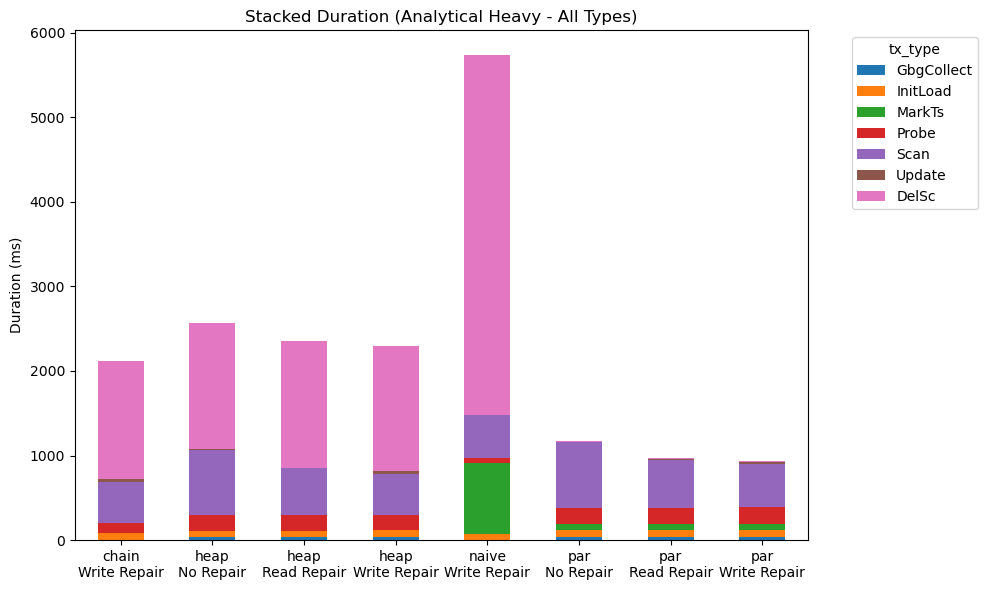

In [ ]:
import subprocess
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re

TITLE = "Analytical Heavy"

# ----------------------------------------
# Build the Rust binary
# ----------------------------------------
print("=== Building Rust binary in release mode ===")
build_cmd = ["cargo", "build", "--release", "--bin", "htap_wkld"]
result = subprocess.run(build_cmd, capture_output=True, text=True)
if result.returncode != 0:
    print("[ERROR] cargo build failed.\n", result.stderr)
    raise SystemExit(1)
print("Cargo build completed successfully.\n")


BASE_ARGS = [
    "--txn-count", "40",  
    "--warehouse-count", "4" # linear to base table size
]
REPEAT=1
BIN = Path("../../../target/release/htap_wkld")
TABLE_TYPES = [ "naive", "heap", "par", "chain"]

from bench_script_functions import run_and_collect, prepare_plot_data, draw_stack_bar

def plot_all2(df):
    color_map, repair_hatches, repair_types, table_types, unique_idx, x_labels, dict_labels = prepare_plot_data(df)

    groups = []
    for table_type in table_types:
        if table_type in ["chain", "naive"]:
            groups.append((table_type, "Write Repair"))
        else:
            for repair_type in repair_types:
                groups.append((table_type, repair_type))

    print(groups)
    type_and_durations = []
    for i, (table_type, repair_type) in enumerate(groups):
        if table_type in ["chain", "naive"] and repair_type != "Write Repair":
            continue

        df_group = df[(df['table_type'] == table_type) & (df['repair_type'] == repair_type)]

        scan_count = 0

        for idx in unique_idx:
            df_row = df_group[df_group['idx'] == idx]
            duration = df_row['duration_ms'].values[0] if not df_row.empty else 0
            label = dict_labels[idx]
            cur_tx_type = label['tx_type']

            # line = {"table_type": table_type, "repair_type": repair_type, "duration_ms":duration, "tx_type": cur_tx_type, "idx": label["idx"], "optional": label["optional"] }
            line = {"table_type": table_type, "repair_type": repair_type, "duration_ms":duration, "tx_type": cur_tx_type, "idx": label["idx"], "optional": label["optional"] }
            type_and_durations.append(line)
    # print(type_and_durations)
    df = pd.DataFrame(type_and_durations)

    result = (
        df.groupby(["table_type", "repair_type", "tx_type"], as_index=False)
        .agg(duration_ms=("duration_ms", lambda x: x.sum())) #  if x.name[2] == "Update" or x.name[2] == "Probe" else x.mean()
    )
    display(result)

    draw_stack_bar(result, TITLE,  "All Types")

added_args = [
    "--update-ratio", "0.005",  # update ratio, % of base table
    "--probe-ratio", "0.005",
    "--analytical-ratio", "0.9",
    "--scan-count", "9",
    "--delta-count", "9"
]

df = run_and_collect(BIN, TABLE_TYPES, BASE_ARGS + added_args, REPEAT)
# Display the resulting DataFrame
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
plot_all2(df)




# Stacked Bar Chart  -- transactional

=== Building Rust binary in release mode ===
Cargo build completed successfully.

Running for table_type=naive with 3 repeats...
   - Trail 1/3
['../../../target/release/htap_wkld', '--op-ratio', '0.005', '--txn-count', '40', '--warehouse-count', '35', '--analytical-ratio', '0.15', '--scan-count', '2', '--table-type', 'naive']


-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 232323223
-----------------------------------------------------------------------

Update ratio: 0.005
Analytical ratio: 0.15
Number of transactions (max Timestamp value): 40
Number of each scan transactions: 2

-----------------------------------------------------------------------

txs:
idx:   0, tx_id:   0, tx_ts:   0, tx_type:   InitLoad, Insert count: 1050000
idx:   1, tx_id:   1, tx_ts:   1, tx_type:     MarkTs, Mark Ts: 1
idx:   2, tx_id:   2, tx_ts:   2, tx_type:     Update, Update count: 5250
idx:   3, tx_id:   3, tx_ts:   3, tx_type:     Update, Update count: 5250
idx:   4, tx_id:   4, tx_ts:   4, tx_type:     Update, Update count: 5250
idx:   5, tx_id:   5, tx_ts:   5, tx_type:     Update, Update count: 5250
idx:   6, tx_id:   6, tx_ts:   6, tx_type:      Probe, Probe count: 5250 at read_ts: 1
idx:   7, tx_id:   7, tx_ts:   7, tx_type:     Update, Update count: 5250
idx: 

,table_type,repair_type,tx_type,duration_ms
0,chain,Write Repair,DelSc,3678.340009
1,chain,Write Repair,GbgCollect,1.762980
2,chain,Write Repair,InitLoad,742.018287
3,chain,Write Repair,MarkTs,0.000000
4,chain,Write Repair,Probe,2198.034025
5,chain,Write Repair,Scan,1243.217851
6,chain,Write Repair,Update,2821.936624
7,heap,No Repair,DelSc,4173.300146
8,heap,No Repair,GbgCollect,399.639859
9,heap,No Repair,InitLoad,749.300956


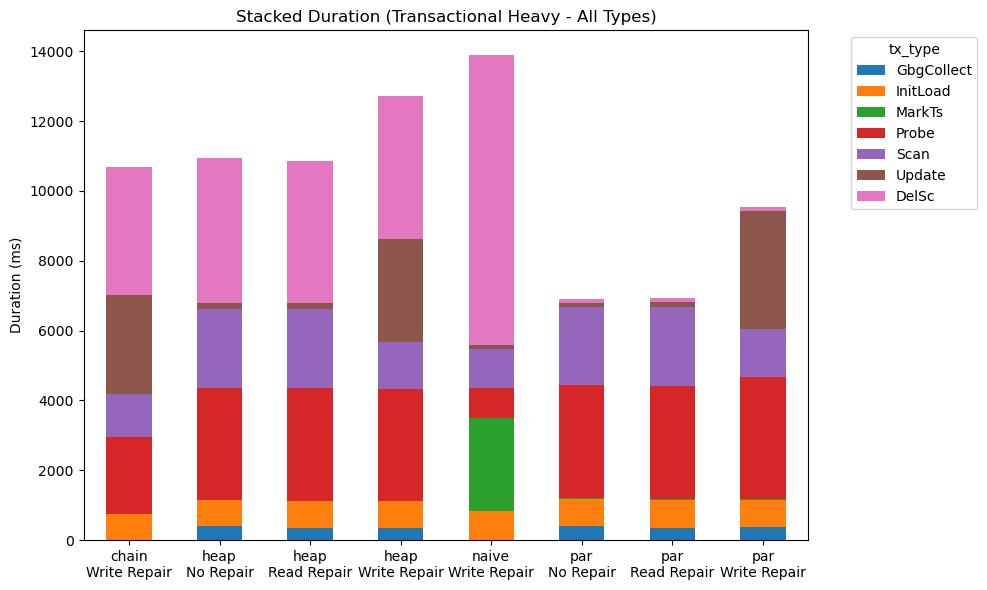

In [ ]:
import subprocess
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re

TITLE = "Transactional Heavy"

# ----------------------------------------
# Build the Rust binary
# ----------------------------------------
print("=== Building Rust binary in release mode ===")
build_cmd = ["cargo", "build", "--release", "--bin", "htap_wkld"]
result = subprocess.run(build_cmd, capture_output=True, text=True)
if result.returncode != 0:
    print("[ERROR] cargo build failed.\n", result.stderr)
    raise SystemExit(1)
print("Cargo build completed successfully.\n")


BASE_ARGS = [
    "--txn-count", "40",  
    "--warehouse-count", "35" # linear to base table size
]
REPEAT=3
BIN = Path("../../../target/release/htap_wkld")
TABLE_TYPES = [ "naive", "heap", "par", "chain"]

from bench_script_functions import run_and_collect, prepare_plot_data, draw_stack_bar

def plot_all2(df):
    color_map, repair_hatches, repair_types, table_types, unique_idx, x_labels, dict_labels = prepare_plot_data(df)

    groups = []
    for table_type in table_types:
        if table_type in ["chain", "naive"]:
            groups.append((table_type, "Write Repair"))
        else:
            for repair_type in repair_types:
                groups.append((table_type, repair_type))

    print(groups)
    type_and_durations = []
    for i, (table_type, repair_type) in enumerate(groups):
        if table_type in ["chain", "naive"] and repair_type != "Write Repair":
            continue

        df_group = df[(df['table_type'] == table_type) & (df['repair_type'] == repair_type)]

        scan_count = 0

        for idx in unique_idx:
            df_row = df_group[df_group['idx'] == idx]
            duration = df_row['duration_ms'].values[0] if not df_row.empty else 0
            label = dict_labels[idx]
            cur_tx_type = label['tx_type']

            # line = {"table_type": table_type, "repair_type": repair_type, "duration_ms":duration, "tx_type": cur_tx_type, "idx": label["idx"], "optional": label["optional"] }
            line = {"table_type": table_type, "repair_type": repair_type, "duration_ms":duration, "tx_type": cur_tx_type, "idx": label["idx"], "optional": label["optional"] }
            type_and_durations.append(line)
    # print(type_and_durations)
    df = pd.DataFrame(type_and_durations)

    result = (
        df.groupby(["table_type", "repair_type", "tx_type"], as_index=False)
        .agg(duration_ms=("duration_ms", lambda x: x.sum())) # if x.name[2] == "Update" or x.name[2] == "Probe" else x.mean()
    )
    display(result)

    draw_stack_bar(result, TITLE, "All Types")

added_args = [
    "--analytical-ratio", "0.15",
    "--scan-count", "2",
    "--delta-count", "2",
    "--update-ratio", "0.005",  # update ratio, % of base table
    "--probe-ratio", "0.005"
]

df = run_and_collect(BIN, TABLE_TYPES, BASE_ARGS + added_args, REPEAT)
# Display the resulting DataFrame
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
plot_all2(df)




# Stacked Bar Chart -- Hybrid

=== Building Rust binary in release mode ===
Cargo build completed successfully.

Running for table_type=naive with 3 repeats...
   - Trail 1/3
['../../../target/release/htap_wkld', '--op-ratio', '0.005', '--txn-count', '40', '--warehouse-count', '35', '--analytical-ratio', '0.5', '--scan-count', '5', '--table-type', 'naive']


-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 232323223
-----------------------------------------------------------------------

Update ratio: 0.005
Analytical ratio: 0.5
Number of transactions (max Timestamp value): 40
Number of each scan transactions: 5

-----------------------------------------------------------------------

txs:
idx:   0, tx_id:   0, tx_ts:   0, tx_type:   InitLoad, Insert count: 1050000
idx:   1, tx_id:   1, tx_ts:   1, tx_type:     MarkTs, Mark Ts: 1
idx:   2, tx_id:   2, tx_ts:   2, tx_type:     Update, Update count: 5250
idx:   3, tx_id:   3, tx_ts:   3, tx_type:      Probe, Probe count: 5250 at read_ts: 1
idx:   4, tx_id:   4, tx_ts:   4, tx_type:     Update, Update count: 5250
idx:   5, tx_id:   5, tx_ts:   5, tx_type:      Probe, Probe count: 5250 at read_ts: 1
idx:   6, tx_id:   6, tx_ts:   6, tx_type:     Update, Update count: 5250
idx:   7, tx_id:   7, tx_ts:   7, tx_type:     Update, Update count

,table_type,repair_type,tx_type,duration_ms
0,chain,Write Repair,DelSc,11679.267167
1,chain,Write Repair,GbgCollect,0.902693
2,chain,Write Repair,InitLoad,741.337148
3,chain,Write Repair,MarkTs,0.000000
4,chain,Write Repair,Probe,5955.160049
5,chain,Write Repair,Scan,2933.228471
6,chain,Write Repair,Update,1879.297977
7,heap,No Repair,DelSc,12998.602665
8,heap,No Repair,GbgCollect,366.036125
9,heap,No Repair,InitLoad,744.218500


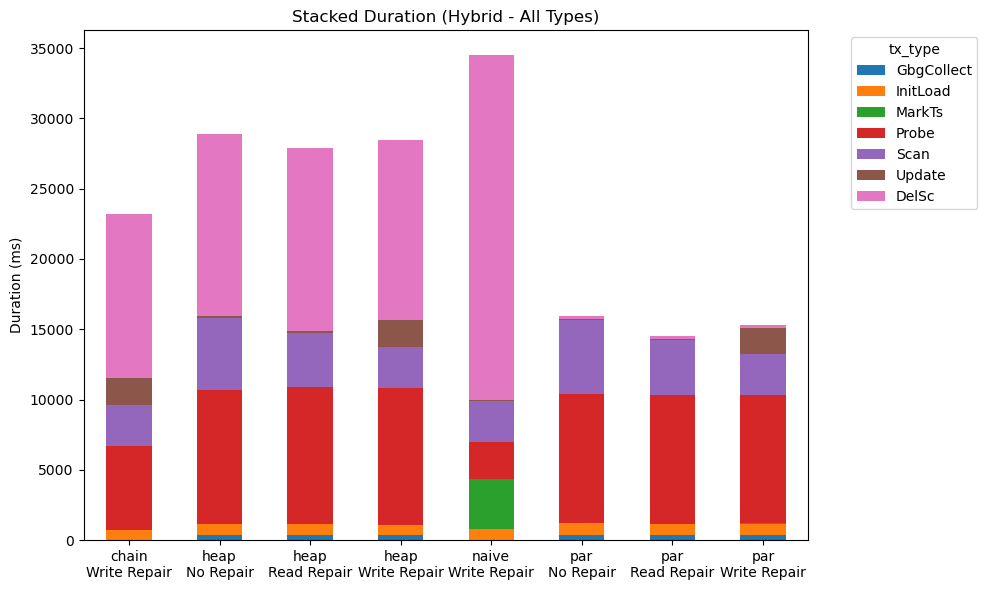

In [ ]:
import subprocess
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re

TITLE = "Hybrid"

# ----------------------------------------
# Build the Rust binary
# ----------------------------------------
print("=== Building Rust binary in release mode ===")
build_cmd = ["cargo", "build", "--release", "--bin", "htap_wkld"]
result = subprocess.run(build_cmd, capture_output=True, text=True)
if result.returncode != 0:
    print("[ERROR] cargo build failed.\n", result.stderr)
    raise SystemExit(1)
print("Cargo build completed successfully.\n")


BASE_ARGS = [
    "--txn-count", "40",  
    "--warehouse-count", "35" # linear to base table size
]
REPEAT=3
BIN = Path("../../../target/release/htap_wkld")
TABLE_TYPES = [ "naive", "heap", "par", "chain"]

from bench_script_functions import run_and_collect, prepare_plot_data, draw_stack_bar

def plot_all2(df):
    color_map, repair_hatches, repair_types, table_types, unique_idx, x_labels, dict_labels = prepare_plot_data(df)

    groups = []
    for table_type in table_types:
        if table_type in ["chain", "naive"]:
            groups.append((table_type, "Write Repair"))
        else:
            for repair_type in repair_types:
                groups.append((table_type, repair_type))

    print(groups)
    type_and_durations = []
    for i, (table_type, repair_type) in enumerate(groups):
        if table_type in ["chain", "naive"] and repair_type != "Write Repair":
            continue

        df_group = df[(df['table_type'] == table_type) & (df['repair_type'] == repair_type)]

        scan_count = 0

        for idx in unique_idx:
            df_row = df_group[df_group['idx'] == idx]
            duration = df_row['duration_ms'].values[0] if not df_row.empty else 0
            label = dict_labels[idx]
            cur_tx_type = label['tx_type']

            # line = {"table_type": table_type, "repair_type": repair_type, "duration_ms":duration, "tx_type": cur_tx_type, "idx": label["idx"], "optional": label["optional"] }
            line = {"table_type": table_type, "repair_type": repair_type, "duration_ms":duration, "tx_type": cur_tx_type, "idx": label["idx"], "optional": label["optional"] }
            type_and_durations.append(line)
    # print(type_and_durations)
    df = pd.DataFrame(type_and_durations)

    result = (
        df.groupby(["table_type", "repair_type", "tx_type"], as_index=False)
        .agg(duration_ms=("duration_ms", lambda x: x.sum())) # if x.name[2] == "Update" or x.name[2] == "Probe" else x.mean()
    )
    display(result)

    draw_stack_bar(result, TITLE, "All Types")

added_args = [
    "--analytical-ratio", "0.5",
    "--scan-count", "5",
    "--delta-count", "5",
    "--probe-ratio", "0.005",
    "--update-ratio", "0.005"
]

df = run_and_collect(BIN, TABLE_TYPES, BASE_ARGS + added_args, REPEAT)
# Display the resulting DataFrame
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
plot_all2(df)




# Stack Bar Chart -- Extremely Transactional

=== Building Rust binary in release mode ===
Cargo build completed successfully.

Running for table_type=naive with 3 repeats...
   - Trail 1/3
['../../../target/release/htap_wkld', '--op-ratio', '0.04', '--txn-count', '40', '--warehouse-count', '35', '--analytical-ratio', '0.15', '--scan-count', '2', '--table-type', 'naive']
-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 232323223
-----------------------------------------------------------------------

Update ratio: 0.04
Analytical ratio: 0.15
Number of transactions (max Timestamp value): 40
Number of each scan transactions: 2

-----------------------------------------------------------------------

txs:
idx:   0, tx_id:   0, tx_ts:   0, tx_type:   InitLoad, Insert count: 1050000
idx:   1, tx_id:   1, tx_ts:   1, tx_type:     MarkTs, Mark Ts: 1
idx:   2, tx_id:   2, tx_ts:   2, tx_type:     Update, Update count: 42000
idx:   3, tx_id:   3, tx_ts:   3, tx_type:     Update, Updat

,table_type,repair_type,tx_type,duration_ms
0,chain,Write Repair,DelSc,4556.135058
1,chain,Write Repair,GbgCollect,13.725837
2,chain,Write Repair,InitLoad,746.787017
3,chain,Write Repair,MarkTs,0.000000
4,chain,Write Repair,Probe,4845.357631
5,chain,Write Repair,Scan,1168.501616
6,chain,Write Repair,Update,5807.104034
7,heap,No Repair,DelSc,6484.960118
8,heap,No Repair,GbgCollect,874.671318
9,heap,No Repair,InitLoad,756.328702


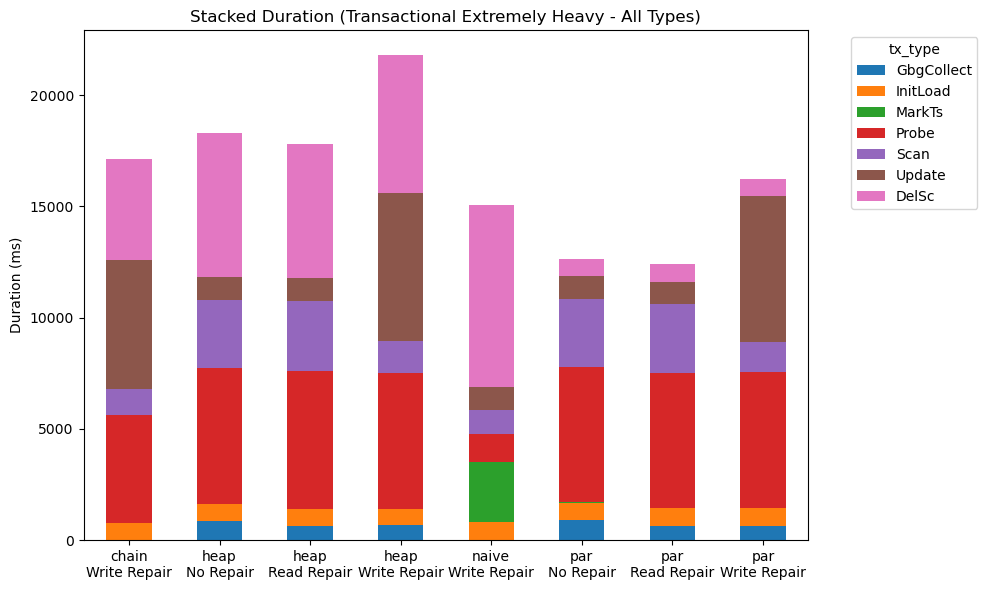

In [ ]:
import subprocess
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re

TITLE = "Transactional Extremely Heavy"

# ----------------------------------------
# Build the Rust binary
# ----------------------------------------
print("=== Building Rust binary in release mode ===")
build_cmd = ["cargo", "build", "--release", "--bin", "htap_wkld"]
result = subprocess.run(build_cmd, capture_output=True, text=True)
if result.returncode != 0:
    print("[ERROR] cargo build failed.\n", result.stderr)
    raise SystemExit(1)
print("Cargo build completed successfully.\n")


BASE_ARGS = [
    "--txn-count", "40",  
    "--warehouse-count", "35" # linear to base table size
]
REPEAT=3
BIN = Path("../../../target/release/htap_wkld")
TABLE_TYPES = [ "naive", "heap", "par", "chain"]

from bench_script_functions import run_and_collect, prepare_plot_data, draw_stack_bar

def plot_all2(df):
    color_map, repair_hatches, repair_types, table_types, unique_idx, x_labels, dict_labels = prepare_plot_data(df)

    groups = []
    for table_type in table_types:
        if table_type in ["chain", "naive"]:
            groups.append((table_type, "Write Repair"))
        else:
            for repair_type in repair_types:
                groups.append((table_type, repair_type))

    print(groups)
    type_and_durations = []
    for i, (table_type, repair_type) in enumerate(groups):
        if table_type in ["chain", "naive"] and repair_type != "Write Repair":
            continue

        df_group = df[(df['table_type'] == table_type) & (df['repair_type'] == repair_type)]

        scan_count = 0

        for idx in unique_idx:
            df_row = df_group[df_group['idx'] == idx]
            duration = df_row['duration_ms'].values[0] if not df_row.empty else 0
            label = dict_labels[idx]
            cur_tx_type = label['tx_type']

            # line = {"table_type": table_type, "repair_type": repair_type, "duration_ms":duration, "tx_type": cur_tx_type, "idx": label["idx"], "optional": label["optional"] }
            line = {"table_type": table_type, "repair_type": repair_type, "duration_ms":duration, "tx_type": cur_tx_type, "idx": label["idx"], "optional": label["optional"] }
            type_and_durations.append(line)
    # print(type_and_durations)
    df = pd.DataFrame(type_and_durations)

    result = (
        df.groupby(["table_type", "repair_type", "tx_type"], as_index=False)
        .agg(duration_ms=("duration_ms", lambda x: x.sum())) # if x.name[2] == "Update" or x.name[2] == "Probe" else x.mean()
    )
    display(result)


    draw_stack_bar(result, TITLE, "All Types")

added_args = [
    "--update-ratio", "0.04",  # update ratio, % of base table
    "--probe-ratio", "0.005",
    "--analytical-ratio", "0.15",
    "--scan-count", "2",
    "--delta-count", "2"
]

df = run_and_collect(BIN, TABLE_TYPES, BASE_ARGS + added_args, REPEAT)
# Display the resulting DataFrame
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
plot_all2(df)




# End timestamp in no_repair

In [ ]:
import subprocess
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re

# ----------------------------------------
# Build the Rust binary
# ----------------------------------------
print("=== Building Rust binary in release mode ===")
build_cmd = ["cargo", "build", "--release", "--bin", "htap_wkld"]
result = subprocess.run(build_cmd, capture_output=True, text=True)
if result.returncode != 0:
    print("[ERROR] cargo build failed.\n", result.stderr)
    raise SystemExit(1)
print("Cargo build completed successfully.\n")


BASE_ARGS = [
    "--update-ratio", "0.01",  # update ratio, % of base table
    "--probe-ratio", "0.005",
    "--txn-count", "40",  
    "--scan-count", "6",  # delta scan count
    "--warehouse-count", "35" # linear to base table size
]
REPEAT=1
BIN = Path("../../../target/release/htap_wkld")
TABLE_TYPES = ["heap", "par"]

def prepare_bar_style(repair_type, table_type, color_map, repair_hatches):
    if repair_type == "Write Repair":
        return {
            'facecolor': color_map[table_type],
            'edgecolor': color_map[table_type],
            'hatch': '',
            'linewidth': 0
        }
    else:
        return {
            'facecolor': 'white',
            'edgecolor': color_map[table_type],
            'hatch': repair_hatches.get(repair_type, ''),
            'linewidth': 0.8
        }
def draw_bar_labels(ax, x_positions, heights, font_size=7):
    for x, y in zip(x_positions, heights):
        if y > 0:  
            ax.text(
                x, 
                y, 
                f"{y:.0f}", 
                ha='center', 
                va='bottom', 
                fontsize=font_size
            )
from bench_script_functions import prepare_plot_data
def plot_all(df):
    table_types = sorted(df['table_type'].unique())
    repair_types = ["No Repair"]
    color_map, repair_hatches, _repair_types, _table_types, unique_idx, x_labels, dict_labels = prepare_plot_data(df)

    groups = []
    for table_type in table_types:
        if table_type in ["chain", "naive"]:
            groups.append((table_type, "Write Repair"))
        else:
            for repair_type in repair_types:
                groups.append((table_type, repair_type))

    type_and_durations = []
    for i, (table_type, repair_type) in enumerate(groups):
        if table_type in ["chain", "naive"] and repair_type != "Write Repair":
            continue

        df_group = df[(df['table_type'] == table_type) & (df['repair_type'] == repair_type)]

        scan_count = 0

        for idx in unique_idx:
            df_row = df_group[df_group['idx'] == idx]
            duration = df_row['duration_ms'].values[0] if not df_row.empty else 0
            label = dict_labels[idx]
            cur_tx_type = label['tx_type']

            # line = {"table_type": table_type, "repair_type": repair_type, "duration_ms":duration, "tx_type": cur_tx_type, "idx": label["idx"], "optional": label["optional"] }
            line = {"table_type": table_type, "repair_type": repair_type, "duration_ms":duration, "tx_type": cur_tx_type, "idx": label["idx"], "optional": label["optional"] }
            type_and_durations.append(line)
    # print(type_and_durations)
    df = pd.DataFrame(type_and_durations)

    result = (
        df.groupby(["table_type", "repair_type", "tx_type"], as_index=False)
        .agg(duration_ms=("duration_ms", lambda x: x.sum())) # if x.name[2] == "Update" or x.name[2] == "Probe" else x.mean()
    )
    display(result)

new_args = BASE_ARGS + ["--space-stat", "on"]

df1 = run_and_collect(BIN, TABLE_TYPES, new_args, REPEAT)

# Build with no_endtimestamp flag
print("=== Building Rust binary in release mode ===")
build_cmd = ["cargo", "build", "--release", "--features", "remove_end_ts_in_no_repair", "--bin", "htap_wkld"]
result = subprocess.run(build_cmd, capture_output=True, text=True)
if result.returncode != 0:
    print("[ERROR] cargo build failed.\n", result.stderr)
    raise SystemExit(1)
print("Cargo build completed successfully.\n")


df2 = run_and_collect(BIN, TABLE_TYPES, new_args, REPEAT)
# Display the resulting DataFrame
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
display(df1)
display(df2)
plot_all(df1)
plot_all(df2)

# [Space Statistics] StatCollector { total_space: 152567808, all_versions_space: 124584000, valid_space: 107400000, header_space: 32592 }
# [Space Statistics] StatCollector { total_space: 150732800, all_versions_space: 124584000, valid_space: 107400000, header_space: 32200 }

=== Building Rust binary in release mode ===
Cargo build completed successfully.

Running for table_type=heap with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--op-ratio', '0.01', '--txn-count', '40', '--scan-count', '6', '--warehouse-count', '35', '--space-stat', 'on', '--table-type', 'heap']


-----------------------------------------------------------------------
Hash table type: Heap
Rng seed: 232323223
-----------------------------------------------------------------------

Update ratio: 0.01
Analytical ratio: 0.4
Number of transactions (max Timestamp value): 40
Number of each scan transactions: 6

-----------------------------------------------------------------------

txs:
idx:   0, tx_id:   0, tx_ts:   0, tx_type:   InitLoad, Insert count: 1050000
idx:   1, tx_id:   1, tx_ts:   1, tx_type:     MarkTs, Mark Ts: 1
idx:   2, tx_id:   2, tx_ts:   2, tx_type:     Update, Update count: 10500
idx:   3, tx_id:   3, tx_ts:   3, tx_type:     Update, Update count: 10500
idx:   4, tx_id:   4, tx_ts:   4, tx_type:     Update, Update count: 10500
idx:   5, tx_id:   5, tx_ts:   5, tx_type:     Update, Update count: 10500
idx:   6, tx_id:   6, tx_ts:   6, tx_type:      Probe, Probe count: 7350 at read_ts: 1
idx:   7, tx_id:   7, tx_ts:   7, tx_type:     Update, Update count: 10500
idx

,idx,tx_id,tx_type,repair_type,table_type,duration_ms,count,read_ts,from_ts,to_ts
0,0,0,InitLoad,No Repair,heap,759.339561,1050000.0,NaN,NaN,NaN
1,1,1,MarkTs,No Repair,heap,0.000000,NaN,1.0,NaN,NaN
2,2,2,Update,No Repair,heap,61.606059,10500.0,NaN,NaN,NaN
3,3,3,Update,No Repair,heap,7.831627,10500.0,NaN,NaN,NaN
4,4,4,Update,No Repair,heap,7.869104,10500.0,NaN,NaN,NaN
5,5,5,Update,No Repair,heap,7.873942,10500.0,NaN,NaN,NaN
6,6,6,Probe,No Repair,heap,893.029319,7350.0,1.0,NaN,NaN
7,7,7,Update,No Repair,heap,8.371071,10500.0,NaN,NaN,NaN
8,8,8,Update,No Repair,heap,8.243461,10500.0,NaN,NaN,NaN
9,9,9,Probe,No Repair,heap,913.956848,7350.0,1.0,NaN,NaN


,idx,tx_id,tx_type,repair_type,table_type,duration_ms,count,read_ts,from_ts,to_ts
0,0,0,InitLoad,No Repair,heap,737.063799,1050000.0,NaN,NaN,NaN
1,1,1,MarkTs,No Repair,heap,0.000000,NaN,1.0,NaN,NaN
2,2,2,Update,No Repair,heap,11.620876,10500.0,NaN,NaN,NaN
3,3,3,Update,No Repair,heap,11.946323,10500.0,NaN,NaN,NaN
4,4,4,Update,No Repair,heap,11.731118,10500.0,NaN,NaN,NaN
5,5,5,Update,No Repair,heap,11.974270,10500.0,NaN,NaN,NaN
6,6,6,Probe,No Repair,heap,910.872060,7350.0,1.0,NaN,NaN
7,7,7,Update,No Repair,heap,12.494291,10500.0,NaN,NaN,NaN
8,8,8,Update,No Repair,heap,12.158619,10500.0,NaN,NaN,NaN
9,9,9,Probe,No Repair,heap,897.952092,7350.0,1.0,NaN,NaN


,table_type,repair_type,tx_type,duration_ms
0,heap,No Repair,DelSc,17685.419699
1,heap,No Repair,InitLoad,759.339561
2,heap,No Repair,MarkTs,0.000000
3,heap,No Repair,Probe,7963.514433
4,heap,No Repair,Scan,6543.489280
5,heap,No Repair,Update,257.370310
6,par,No Repair,DelSc,923.587468
7,par,No Repair,InitLoad,785.394758
8,par,No Repair,MarkTs,37.567305
9,par,No Repair,Probe,5909.311498


,table_type,repair_type,tx_type,duration_ms
0,heap,No Repair,DelSc,112.507231
1,heap,No Repair,InitLoad,737.063799
2,heap,No Repair,MarkTs,0.000000
3,heap,No Repair,Probe,7912.491016
4,heap,No Repair,Scan,6571.633028
5,heap,No Repair,Update,298.037240
6,par,No Repair,DelSc,10.554833
7,par,No Repair,InitLoad,765.980068
8,par,No Repair,MarkTs,37.126706
9,par,No Repair,Probe,5891.797676


# Stacked Bar Chart  -- Extremely Reuse of Time

=== Building Rust binary in release mode ===
Cargo build completed successfully.

Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--txn-count', '40', '--warehouse-count', '5', '--analytical-ratio', '0.9', '--scan-count', '10', '--delta-count', '2', '--update-ratio', '0.005', '--probe-ratio', '0.01', '--table-type', 'naive']
-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 232323223
-----------------------------------------------------------------------

Update ratio: 0.005
Analytical ratio: 0.9
Number of transactions (max Timestamp value): 40
Number of each scan transactions: 10

-----------------------------------------------------------------------

txs:
idx:   0, tx_id:   0, tx_ts:   0, tx_type:   InitLoad, Insert count: 150000
idx:   1, tx_id:   1, tx_ts:   1, tx_type:     MarkTs, Mark Ts: 1
idx:   2, tx_id:   2, tx_ts:   2, tx_type:     Update, Update count: 750
idx:   3, t

,table_type,repair_type,tx_type,duration_ms
0,heap,No Repair,DelSc,377.354231
1,heap,No Repair,GbgCollect,37.213034
2,heap,No Repair,InitLoad,101.432474
3,heap,No Repair,MarkTs,0.000000
4,heap,No Repair,Probe,374.954131
5,heap,No Repair,Scan,1132.429283
6,heap,No Repair,Update,8.389866
7,heap,Read Repair,DelSc,371.593761
8,heap,Read Repair,GbgCollect,36.715296
9,heap,Read Repair,InitLoad,101.518473


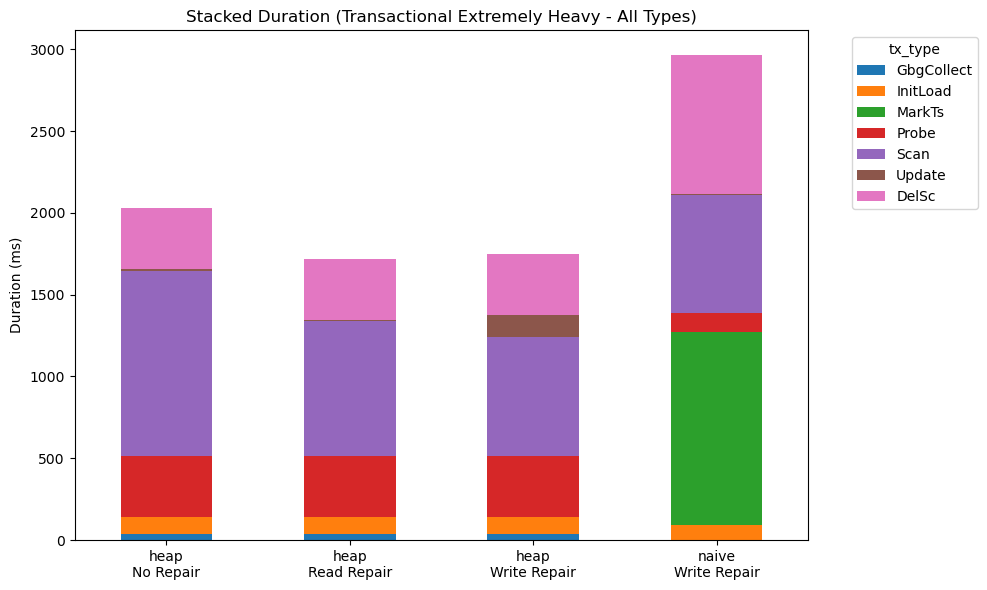

In [2]:
import subprocess
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re

TITLE = "Transactional Extremely Heavy"

# ----------------------------------------
# Build the Rust binary
# ----------------------------------------
print("=== Building Rust binary in release mode ===")
build_cmd = ["cargo", "build", "--release", "--bin", "htap_wkld"]
result = subprocess.run(build_cmd, capture_output=True, text=True)
if result.returncode != 0:
    print("[ERROR] cargo build failed.\n", result.stderr)
    raise SystemExit(1)
print("Cargo build completed successfully.\n")


BASE_ARGS = [
    "--txn-count", "40",  
    "--warehouse-count", "5" # linear to base table size
]
REPEAT=1
BIN = Path("../../../target/release/htap_wkld")
TABLE_TYPES = [ "naive", "heap"]

from bench_script_functions import run_and_collect, prepare_plot_data, draw_stack_bar

def plot_all2(df):
    color_map, repair_hatches, repair_types, table_types, unique_idx, x_labels, dict_labels = prepare_plot_data(df)

    groups = []
    for table_type in table_types:
        if table_type in ["chain", "naive"]:
            groups.append((table_type, "Write Repair"))
        else:
            for repair_type in repair_types:
                groups.append((table_type, repair_type))

    print(groups)
    type_and_durations = []
    for i, (table_type, repair_type) in enumerate(groups):
        if table_type in ["chain", "naive"] and repair_type != "Write Repair":
            continue

        df_group = df[(df['table_type'] == table_type) & (df['repair_type'] == repair_type)]

        scan_count = 0

        for idx in unique_idx:
            df_row = df_group[df_group['idx'] == idx]
            duration = df_row['duration_ms'].values[0] if not df_row.empty else 0
            label = dict_labels[idx]
            cur_tx_type = label['tx_type']

            # line = {"table_type": table_type, "repair_type": repair_type, "duration_ms":duration, "tx_type": cur_tx_type, "idx": label["idx"], "optional": label["optional"] }
            line = {"table_type": table_type, "repair_type": repair_type, "duration_ms":duration, "tx_type": cur_tx_type, "idx": label["idx"], "optional": label["optional"] }
            type_and_durations.append(line)
    # print(type_and_durations)
    df = pd.DataFrame(type_and_durations)

    result = (
        df.groupby(["table_type", "repair_type", "tx_type"], as_index=False)
        .agg(duration_ms=("duration_ms", lambda x: x.sum())) # if x.name[2] == "Update" or x.name[2] == "Probe" else x.mean()
    )
    display(result)

    draw_stack_bar(result, TITLE, "All Types")

added_args = [
    "--analytical-ratio", "0.9",
    "--scan-count", "10",
    "--delta-count", "2",
    "--update-ratio", "0.005",  # update ratio, % of base table
    "--probe-ratio", "0.01"
]

df = run_and_collect(BIN, TABLE_TYPES, BASE_ARGS + added_args, REPEAT)
# Display the resulting DataFrame
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
plot_all2(df)




# DELTA TRACEOFF -- reuse of snapshots

=== Building Rust binary in release mode ===
Cargo build completed successfully.

Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--txn-count', '40', '--update-ratio', '0.005', '--delta-count', '2', '--warehouse-count', '35', '--analytical-ratio', '0.5', '--probe-ratio', '0.001', '--scan-count', '3', '--table-type', 'naive']
-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 232323223
-----------------------------------------------------------------------

Update ratio: 0.005
Analytical ratio: 0.5
Number of transactions (max Timestamp value): 40
Number of each scan transactions: 3

-----------------------------------------------------------------------

txs:
idx:   0, tx_id:   0, tx_ts:   0, tx_type:   InitLoad, Insert count: 1050000
idx:   1, tx_id:   1, tx_ts:   1, tx_type:     MarkTs, Mark Ts: 1
idx:   2, tx_id:   2, tx_ts:   2, tx_type:     Update, Update count: 5250
idx:   3,

,table_type,repair_type,tx_type,duration_ms_first,duration_ms_last,delta,pct_contribution
0,chain,No Repair,DeltaScan,3927.693840,4204.507331,276.813491,4.474464e-01
1,chain,No Repair,GbgCollect,0.813004,0.873980,0.060976,9.856272e-05
2,chain,No Repair,InitLoad,745.235324,753.516228,8.280904,1.338540e-02
3,chain,No Repair,MarkTs,0.000000,0.000000,0.000000,0.000000e+00
4,chain,No Repair,Probe,974.811584,38442.907025,37468.095441,6.056412e+01
5,chain,No Repair,Scan,2049.502137,26249.375467,24199.873330,3.911712e+01
6,chain,No Repair,Update,1976.544763,1888.594731,-87.950032,-1.421640e-01
7,chain,Read Repair,DeltaScan,3903.156183,4196.499124,293.342941,5.040687e-01
8,chain,Read Repair,GbgCollect,0.853915,0.822386,-0.031529,-5.417816e-05
9,chain,Read Repair,InitLoad,749.807379,754.084340,4.276961,7.349357e-03


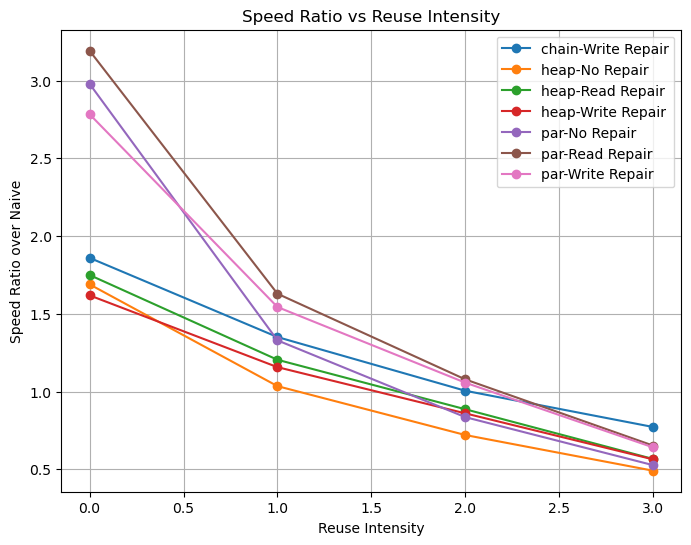

/tmp/ipykernel_3424772/3748207366.py:156: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["group"] = df["table_type"] + "\n" + df["repair_type"]


tx_type,DeltaScan,GbgCollect,InitLoad,MarkTs,Probe,Scan,Update
group,,,,,,,
chain\nWrite Repair,0.434489,-0.000033,0.006054,2.399011e-06,62.705934,36.844286,0.009268
heap\nNo Repair,0.284847,0.181022,-0.022203,0.000000e+00,60.356872,39.165355,0.034107
heap\nRead Repair,0.511887,0.220763,0.033454,-6.001547e-09,71.353422,27.850968,0.029506
heap\nWrite Repair,0.451068,0.215584,0.026353,-1.492870e-06,72.159153,27.087793,0.060050
par\nNo Repair,0.018559,0.177365,0.005840,8.005708e-03,56.515668,43.259551,0.015011
par\nRead Repair,0.016902,0.235869,0.016224,9.514165e-03,70.112123,29.588472,0.020895
par\nWrite Repair,0.007132,0.213070,-0.002363,3.087112e-03,70.370183,29.403784,0.005107


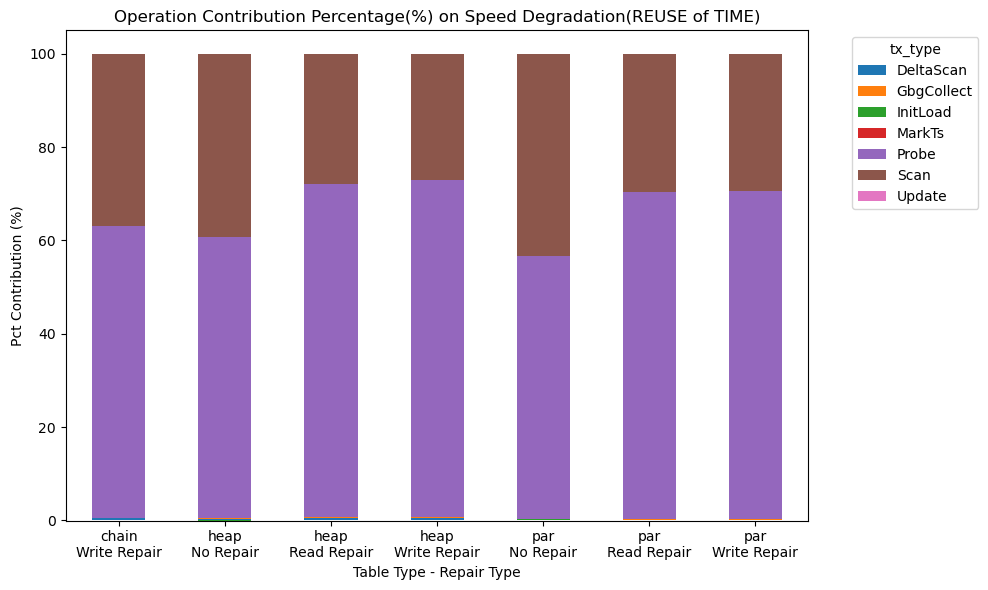

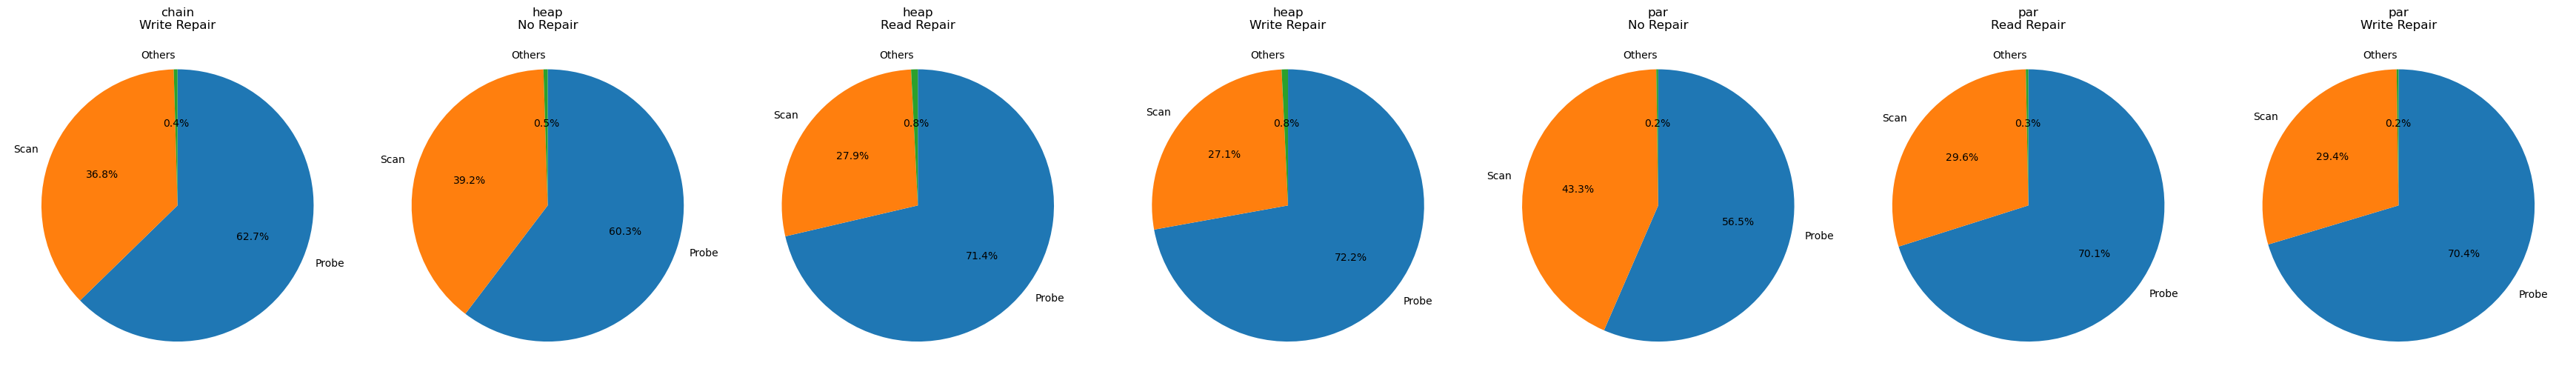

In [1]:
import subprocess
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re

# ----------------------------------------
# Build the Rust binary
# ----------------------------------------
print("=== Building Rust binary in release mode ===")
build_cmd = ["cargo", "build", "--release", "--bin", "htap_wkld"]
result = subprocess.run(build_cmd, capture_output=True, text=True)
if result.returncode != 0:
    print("[ERROR] cargo build failed.\n", result.stderr)
    raise SystemExit(1)
print("Cargo build completed successfully.\n")


BASE_ARGS = [
    "--txn-count", "40",  
    "--update-ratio", "0.005",
    "--delta-count", "2",
    "--warehouse-count", "35", # linear to base table size
    "--analytical-ratio", "0.5"
]
REPEAT=1
BIN = Path("../../../target/release/htap_wkld")
TABLE_TYPES = ["naive", "heap", "par", "chain"] #, "par", "chain"
REUSE_CONFIGS = [("0.001", "3"), ("0.005", "10"), ("0.01", "20"), ("0.04", "40")] # (probe_ratio, scan_count)

from bench_script_functions import run_and_collect
TRANSACTIONAL_TX_TYPE = ['InitLoad', 'Update']
ANALYTICAL_TX_TYPE = ['Probe', 'Scan', 'DeltaScan']

def get_avg(df):
    # display(df)
    table_types = sorted(df['table_type'].unique())
    repair_types = ["No Repair", "Read Repair", "Write Repair"]
    tx_type_groups = ["DeltaScan"]
    groups = []
    for table_type in table_types:
        if table_type in ['naive', 'chain']:
            groups.append((table_type, 'Write Repair'))
        else:
            for repair_type in repair_types:
                groups.append((table_type, repair_type))
    
    durations = []
    for i, (table_type, repair_type) in enumerate(groups):
        if table_type in ["chain", "naive"] and repair_type != "Write Repair":
            continue

        df_group = df[(df['table_type'] == table_type) & (df['repair_type'] == repair_type)]
        
        # DeltaScan only average
        # scan_vals = df_group['duration_ms'].values
        # avg_delta_scan = scan_vals.sum()
        # display(df_group)
        scan_vals = df_group['duration_ms'].sum()
        durations.append((table_type, repair_type, scan_vals)) # table_type, repair_type, avg_duration

        # display(df_group)
    return durations

# get ratio over base_type
def get_ratio(avg, base_type, reuse_intensity):
    result = []
    ratio_col_name = f'speed_ratio_over_{base_type}'
    base = None
    for (table_type, repair_type, avg_dur) in avg:
        if table_type in [base_type]:
            base = avg_dur
    
    for (table_type, repair_type, avg_dur) in avg:
        if table_type not in [base_type]:
            result.append({"reuse_intensity": reuse_intensity, "table_type": table_type, "repair_type": repair_type, ratio_col_name: base/ avg_dur})

    df_res = pd.DataFrame(result)
    return df_res
df_ratio = pd.DataFrame()
df_list = []
update_count = 0
for reuse_intensity, (probe_ratio, scan_count) in enumerate(REUSE_CONFIGS):
    NEW_ARGS = BASE_ARGS.copy()
    NEW_ARGS += ["--probe-ratio", probe_ratio,
                 "--scan-count", scan_count]
    
    df = run_and_collect(BIN, TABLE_TYPES, NEW_ARGS, REPEAT)
    update_count = (
        df[df["tx_type"] == "Update"]
        .groupby(["table_type", "repair_type"])
        .size()
        .iloc[0]  # 只取一个，因为都一样
    )
    # Display the resulting DataFrame
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    pd.set_option('display.max_colwidth', None)
    result = df.groupby(["table_type", "repair_type", "tx_type"])["duration_ms"].sum().reset_index()
    df_avg = get_avg(result)
    # print(aa)
    ratio = get_ratio(df_avg, 'naive', reuse_intensity)
    df_ratio = pd.concat([df_ratio, ratio], ignore_index=True)
    # display(result)
    df_list.append(result)
assert(len(df_list) > 1)
df_first = df_list[0]
df_last = df_list[-1]
merged = pd.merge(
    df_first,
    df_last,
    on=["table_type", "repair_type", "tx_type"],
    how="inner",
    suffixes=("_first", "_last")
)

df_filtered = merged[~(
    (merged["table_type"].isin(["naive", "chain"]) & (merged["repair_type"] != "Write Repair")) | merged["table_type"] == "naive"
)]

merged = df_filtered

# 
merged["delta"] = merged["duration_ms_last"] - merged["duration_ms_first"]

# 
group_total = merged.groupby(["table_type", "repair_type"])["delta"].transform("sum")

# 
merged["pct_contribution"] = merged["delta"] / group_total * 100
display(merged)

# print(f"update_count : {update_count}")


# df_ratio['reuse_intensity'] = df_ratio['reuse_intensity'].astype(float) * update_count
# display(df_ratio)
df = df_ratio.sort_values(by="reuse_intensity")

# (table_type, repair_type) 
plt.figure(figsize=(8,6))
for (table, repair), group in df.groupby(["table_type", "repair_type"]):
    plt.plot(group["reuse_intensity"], group["speed_ratio_over_naive"], 
             marker='o', label=f"{table}-{repair}")

plt.xlabel("Reuse Intensity")
plt.ylabel("Speed Ratio over Naive")
plt.title("Speed Ratio vs Reuse Intensity")
plt.legend()
plt.grid(True)
plt.show()

def stack_bar_chart_for_contribution(df, min_pct=0.02):
    # create a new column combining table_type and repair_type for x labels
    df["group"] = df["table_type"] + "\n" + df["repair_type"]

    # pivot so that tx_type becomes columns, pct_contribution values are stacked
    pivot_df = df.pivot_table(
        index="group",
        columns="tx_type",
        values="pct_contribution",
        aggfunc="sum",
        fill_value=0
    )

    display(pivot_df)

    # plot stacked bar
    ax = pivot_df.plot(
        kind="bar",
        stacked=True,
        figsize=(10, 6)
    )
    
    # add labels and title
    plt.ylabel("Pct Contribution (%)")
    plt.xlabel("Table Type - Repair Type")
    plt.xticks(rotation=0)
    plt.title("Operation Contribution Percentage(%) on Speed Degradation(REUSE of TIME)")
    plt.legend(title="tx_type", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
############################################################################################################
    # create one subplot per group
    n_groups = len(pivot_df)
    fig, axes = plt.subplots(1, n_groups, figsize=(5 * n_groups, 5))

    # if only one group, axes is not iterable
    if n_groups == 1:
        axes = [axes]

    for ax, (group, row) in zip(axes, pivot_df.iterrows()):
        row = row[row > 0]
        row = row / row.sum()

        # merge tiny slices into "Others"
        small = row[row < min_pct]
        row = row[row >= min_pct]
        if len(small) > 0:
            row["Others"] = small.sum()
        
        # draw pie chart
        ax.pie(
            row.values,
            labels=row.index,
            autopct="%1.1f%%",
            startangle=90,
            counterclock=False
        )
        ax.set_title(group)

    plt.tight_layout()
    plt.show()

df_filtered1 = merged[~(
    (merged["table_type"].isin(["naive", "chain"]) & (merged["repair_type"] != "Write Repair"))
)]


df_filtered = df_filtered1[~(
    df_filtered1["table_type"].isin(["naive"])
)]


stack_bar_chart_for_contribution(df_filtered)


# DELTA TRADEOFF -- update ratio

=== Building Rust binary in release mode ===
Cargo build completed successfully.

Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--txn-count', '40', '--scan-count', '6', '--warehouse-count', '35', '--probe-ratio', '0.005', '--update-ratio', '0.005', '--table-type', 'naive']


-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 232323223
-----------------------------------------------------------------------

Update ratio: 0.005
Analytical ratio: 0.4
Number of transactions (max Timestamp value): 40
Number of each scan transactions: 6

-----------------------------------------------------------------------

txs:
idx:   0, tx_id:   0, tx_ts:   0, tx_type:   InitLoad, Insert count: 1050000
idx:   1, tx_id:   1, tx_ts:   1, tx_type:     MarkTs, Mark Ts: 1
idx:   2, tx_id:   2, tx_ts:   2, tx_type:     Update, Update count: 5250
idx:   3, tx_id:   3, tx_ts:   3, tx_type:     MarkTs, Mark Ts: 3
idx:   4, tx_id:   4, tx_ts:   4, tx_type:     Update, Update count: 5250
idx:   5, tx_id:   5, tx_ts:   5, tx_type:     Update, Update count: 5250
idx:   6, tx_id:   6, tx_ts:   6, tx_type:     MarkTs, Mark Ts: 6
idx:   7, tx_id:   7, tx_ts:   7, tx_type:     Update, Update count: 5250
idx:   8, tx_id:   8, tx_ts:   8, t

,table_type,repair_type,tx_type,duration_ms_first,duration_ms_last,delta,pct_contribution
0,chain,No Repair,DeltaScan,15265.622199,16740.333786,1474.711587,25.306407
1,chain,No Repair,GbgCollect,1.073032,6.625051,5.552019,0.095274
2,chain,No Repair,InitLoad,750.339534,757.588723,7.249189,0.124398
3,chain,No Repair,MarkTs,0.002123,0.000000,-0.002123,-0.000036
4,chain,No Repair,Probe,3352.398681,5425.580171,2073.181490,35.576295
5,chain,No Repair,Scan,3563.168253,3549.604328,-13.563925,-0.232760
6,chain,No Repair,Update,2430.425686,4710.721266,2280.295580,39.130423
7,chain,Read Repair,DeltaScan,15142.041714,16765.611759,1623.570045,27.767388
8,chain,Read Repair,GbgCollect,1.038886,6.651282,5.612396,0.095987
9,chain,Read Repair,InitLoad,752.101009,737.011145,-15.089864,-0.258077


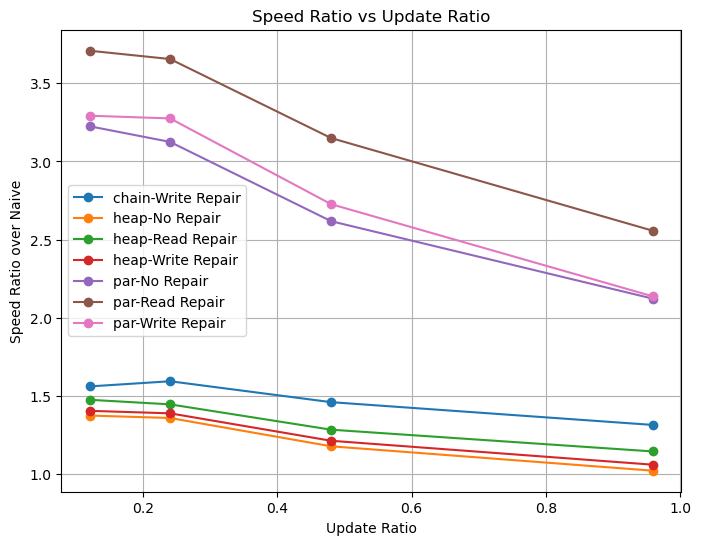

/tmp/ipykernel_3424772/1853444468.py:154: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["group"] = df["table_type"] + "\n" + df["repair_type"]


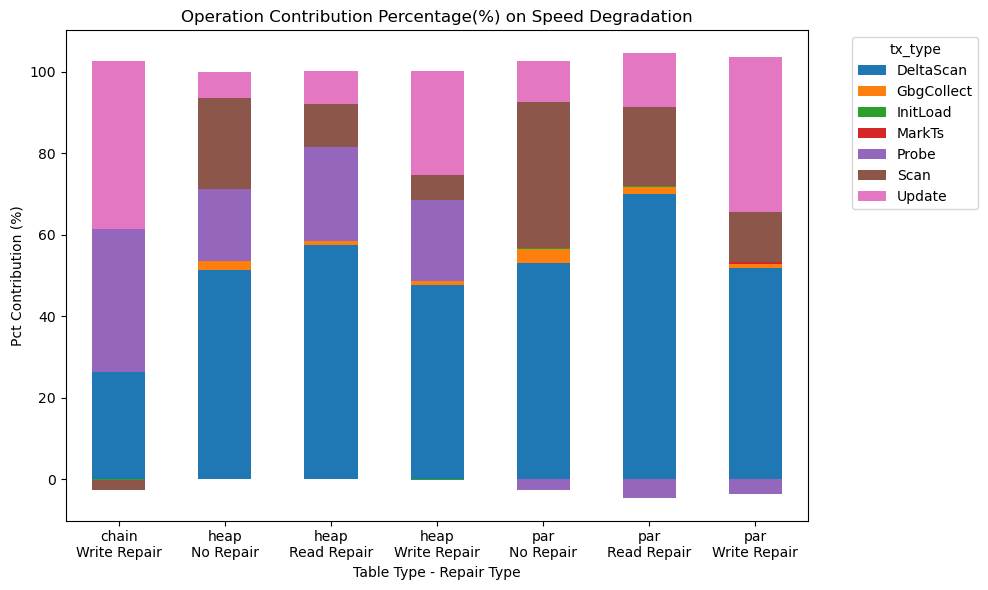

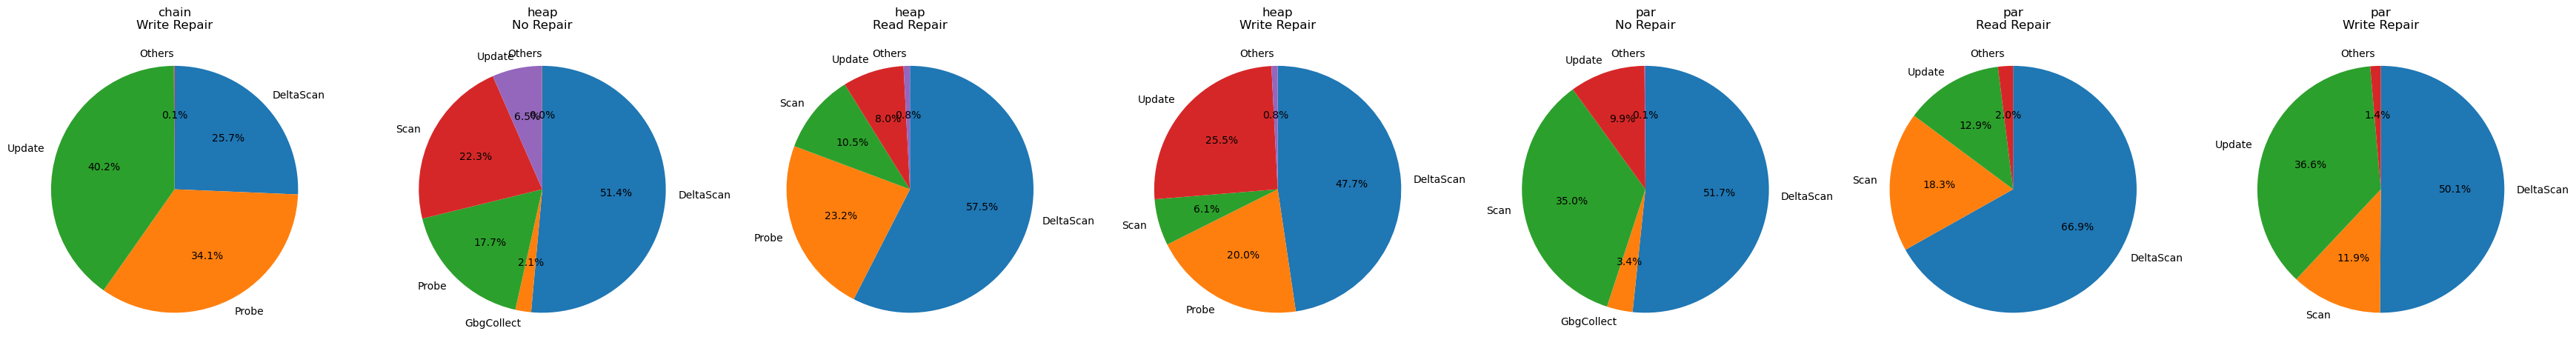

In [2]:
import subprocess
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re

# ----------------------------------------
# Build the Rust binary
# ----------------------------------------
print("=== Building Rust binary in release mode ===")
build_cmd = ["cargo", "build", "--release", "--bin", "htap_wkld"]
result = subprocess.run(build_cmd, capture_output=True, text=True)
if result.returncode != 0:
    print("[ERROR] cargo build failed.\n", result.stderr)
    raise SystemExit(1)
print("Cargo build completed successfully.\n")


BASE_ARGS = [
    "--txn-count", "40",  
    "--scan-count", "6",  # delta scan count
    "--warehouse-count", "35", # linear to base table size
    "--probe-ratio", "0.005",
]
REPEAT=1
BIN = Path("../../../target/release/htap_wkld")
TABLE_TYPES = ["naive", "heap", "par", "chain"] #, "par", "chain"
UPDATE_RATIOS = ["0.005", "0.01", "0.02", "0.04"]

from bench_script_functions import run_and_collect
TRANSACTIONAL_TX_TYPE = ['InitLoad', 'Update']
ANALYTICAL_TX_TYPE = ['Probe', 'Scan', 'DeltaScan']

def get_avg(df):
    # display(df)
    table_types = sorted(df['table_type'].unique())
    repair_types = ["No Repair", "Read Repair", "Write Repair"]
    tx_type_groups = ["DeltaScan"]
    groups = []
    for table_type in table_types:
        if table_type in ['naive', 'chain']:
            groups.append((table_type, 'Write Repair'))
        else:
            for repair_type in repair_types:
                groups.append((table_type, repair_type))
    
    durations = []
    for i, (table_type, repair_type) in enumerate(groups):
        if table_type in ["chain", "naive"] and repair_type != "Write Repair":
            continue

        df_group = df[(df['table_type'] == table_type) & (df['repair_type'] == repair_type)]
        
        # DeltaScan only average
        # scan_vals = df_group['duration_ms'].values
        # avg_delta_scan = scan_vals.sum()
        # display(df_group)
        scan_vals = df_group['duration_ms'].sum()
        durations.append((table_type, repair_type, scan_vals)) # table_type, repair_type, avg_duration

        # display(df_group)
    return durations

# get ratio over base_type
def get_ratio(avg, base_type, update_ratio):
    result = []
    ratio_col_name = f'speed_ratio_over_{base_type}'
    base = None
    for (table_type, repair_type, avg_dur) in avg:
        if table_type in [base_type]:
            base = avg_dur
    
    for (table_type, repair_type, avg_dur) in avg:
        if table_type not in [base_type]:
            result.append({"update_ratio": update_ratio, "table_type": table_type, "repair_type": repair_type, ratio_col_name: base/ avg_dur})

    df_res = pd.DataFrame(result)
    return df_res
df_ratio = pd.DataFrame()
df_list = []
update_count = 0
for update_ratio in UPDATE_RATIOS:
    NEW_ARGS = BASE_ARGS.copy()
    NEW_ARGS += ["--update-ratio", update_ratio]
    
    df = run_and_collect(BIN, TABLE_TYPES, NEW_ARGS, REPEAT)
    update_count = (
        df[df["tx_type"] == "Update"]
        .groupby(["table_type", "repair_type"])
        .size()
        .iloc[0]  # 只取一个，因为都一样
    )
    # Display the resulting DataFrame
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    pd.set_option('display.max_colwidth', None)
    result = df.groupby(["table_type", "repair_type", "tx_type"])["duration_ms"].sum().reset_index()
    df_avg = get_avg(result)
    # print(aa)
    ratio = get_ratio(df_avg, 'naive', update_ratio)
    df_ratio = pd.concat([df_ratio, ratio], ignore_index=True)
    # display(result)
    df_list.append(result)
assert(len(df_list) > 1)
df_first = df_list[0]
df_last = df_list[-1]
merged = pd.merge(
    df_first,
    df_last,
    on=["table_type", "repair_type", "tx_type"],
    how="inner",
    suffixes=("_first", "_last")
)

df_filtered = merged[~(
    (merged["table_type"].isin(["naive", "chain"]) & (merged["repair_type"] != "Write Repair")) | merged["table_type"] == "naive"
)]

merged = df_filtered

# 增长量
merged["delta"] = merged["duration_ms_last"] - merged["duration_ms_first"]

# 总增长（每组 table_type + repair_type）
group_total = merged.groupby(["table_type", "repair_type"])["delta"].transform("sum")

# 每个 tx_type 对增长的百分比贡献
merged["pct_contribution"] = merged["delta"] / group_total * 100
display(merged)

# print(f"update_count : {update_count}")


df_ratio['update_ratio'] = df_ratio['update_ratio'].astype(float) * update_count
# display(df_ratio)
df = df_ratio.sort_values(by="update_ratio")

# 按 (table_type, repair_type) 分组画图
plt.figure(figsize=(8,6))
for (table, repair), group in df.groupby(["table_type", "repair_type"]):
    plt.plot(group["update_ratio"], group["speed_ratio_over_naive"], 
             marker='o', label=f"{table}-{repair}")

plt.xlabel("Update Ratio")
plt.ylabel("Speed Ratio over Naive")
plt.title("Speed Ratio vs Update Ratio")
plt.legend()
plt.grid(True)
plt.show()

def stack_bar_chart_for_contribution(df, min_pct=0.02):
    # create a new column combining table_type and repair_type for x labels
    df["group"] = df["table_type"] + "\n" + df["repair_type"]

    # pivot so that tx_type becomes columns, pct_contribution values are stacked
    pivot_df = df.pivot_table(
        index="group",
        columns="tx_type",
        values="pct_contribution",
        aggfunc="sum",
        fill_value=0
    )

    # plot stacked bar
    ax = pivot_df.plot(
        kind="bar",
        stacked=True,
        figsize=(10, 6)
    )
    
    # add labels and title
    plt.ylabel("Pct Contribution (%)")
    plt.xlabel("Table Type - Repair Type")
    plt.xticks(rotation=0)
    plt.title("Operation Contribution Percentage(%) on Speed Degradation")
    plt.legend(title="tx_type", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
############################################################################################################
    # create one subplot per group
    n_groups = len(pivot_df)
    fig, axes = plt.subplots(1, n_groups, figsize=(5 * n_groups, 5))

    # if only one group, axes is not iterable
    if n_groups == 1:
        axes = [axes]

    for ax, (group, row) in zip(axes, pivot_df.iterrows()):
        row = row[row > 0]
        row = row / row.sum()

        # merge tiny slices into "Others"
        small = row[row < min_pct]
        row = row[row >= min_pct]
        if len(small) > 0:
            row["Others"] = small.sum()
        
        # draw pie chart
        ax.pie(
            row.values,
            labels=row.index,
            autopct="%1.1f%%",
            startangle=90,
            counterclock=False
        )
        ax.set_title(group)

    plt.tight_layout()
    plt.show()

df_filtered1 = merged[~(
    (merged["table_type"].isin(["naive", "chain"]) & (merged["repair_type"] != "Write Repair"))
)]


df_filtered = df_filtered1[~(
    df_filtered1["table_type"].isin(["naive"])
)]


stack_bar_chart_for_contribution(df_filtered)


# DELTA TRADEOFF -- delta scan

=== Building Rust binary in release mode ===
Cargo build completed successfully.

Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--txn-count', '40', '--update-ratio', '0.005', '--warehouse-count', '35', '--delta-count', '3', '--table-type', 'naive']
-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 232323223
-----------------------------------------------------------------------

Update ratio: 0.005
Analytical ratio: 0.4
Number of transactions (max Timestamp value): 40
Number of each scan transactions: 3

-----------------------------------------------------------------------

txs:
idx:   0, tx_id:   0, tx_ts:   0, tx_type:   InitLoad, Insert count: 1050000
idx:   1, tx_id:   1, tx_ts:   1, tx_type:     MarkTs, Mark Ts: 1
idx:   2, tx_id:   2, tx_ts:   2, tx_type:     Update, Update count: 5250
idx:   3, tx_id:   3, tx_ts:   3, tx_type:     MarkTs, Mark Ts: 3
idx:   4, tx_id:   

,table_type,repair_type,tx_type,duration_ms_first,duration_ms_last,delta,pct_contribution
0,chain,No Repair,DeltaScan,6698.959297,36116.248025,29417.288728,99.812603
1,chain,No Repair,GbgCollect,1.052011,1.047824,-0.004187,-0.000014
2,chain,No Repair,InitLoad,749.720712,731.346035,-18.374677,-0.062345
3,chain,No Repair,MarkTs,0.000000,0.000000,0.000000,0.000000
4,chain,No Repair,Probe,6776.369138,6705.731521,-70.637617,-0.239673
5,chain,No Repair,Scan,1741.122122,2035.400192,294.278070,0.998483
6,chain,No Repair,Update,2440.074907,2290.043945,-150.030962,-0.509054
7,chain,Read Repair,DeltaScan,6707.796594,40001.922811,33294.126217,99.592261
8,chain,Read Repair,GbgCollect,1.054900,1.055598,0.000698,0.000002
9,chain,Read Repair,InitLoad,754.146696,755.857464,1.710768,0.005117


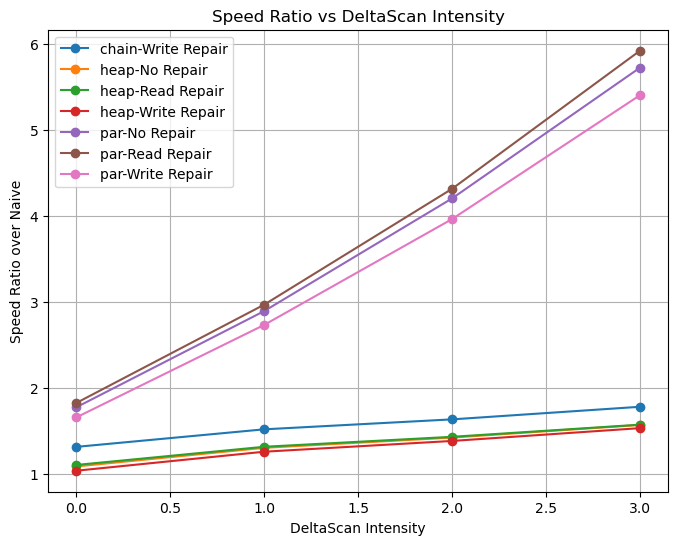

/tmp/ipykernel_3615316/1928245097.py:149: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["group"] = df["table_type"] + "\n" + df["repair_type"]


tx_type,DeltaScan,GbgCollect,InitLoad,MarkTs,Probe,Scan,Update
group,,,,,,,
chain\nWrite Repair,97.648697,0.000093,1.248361,0.000000,0.270009,0.673662,0.159178
heap\nNo Repair,99.868873,0.004752,0.063490,0.000000,0.051828,0.018847,-0.007789
heap\nRead Repair,99.964438,0.009355,-0.041775,0.000000,0.100625,-0.029373,-0.003270
heap\nWrite Repair,99.832866,0.055884,-0.029388,0.000000,0.107701,0.022654,0.010283
par\nNo Repair,99.130338,1.326469,1.042398,-0.042558,-0.420179,-1.012451,-0.024017
par\nRead Repair,110.918427,-0.440542,-0.392295,-0.036800,-9.018121,-1.013535,-0.017134
par\nWrite Repair,106.663027,-0.235050,-2.035497,-0.006810,-6.221020,4.363393,-2.528043


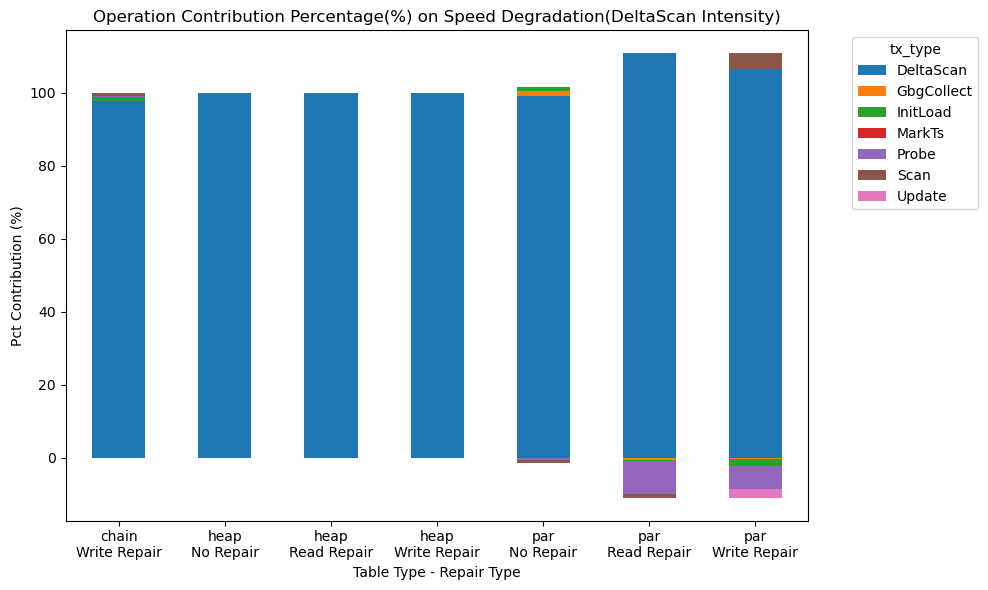

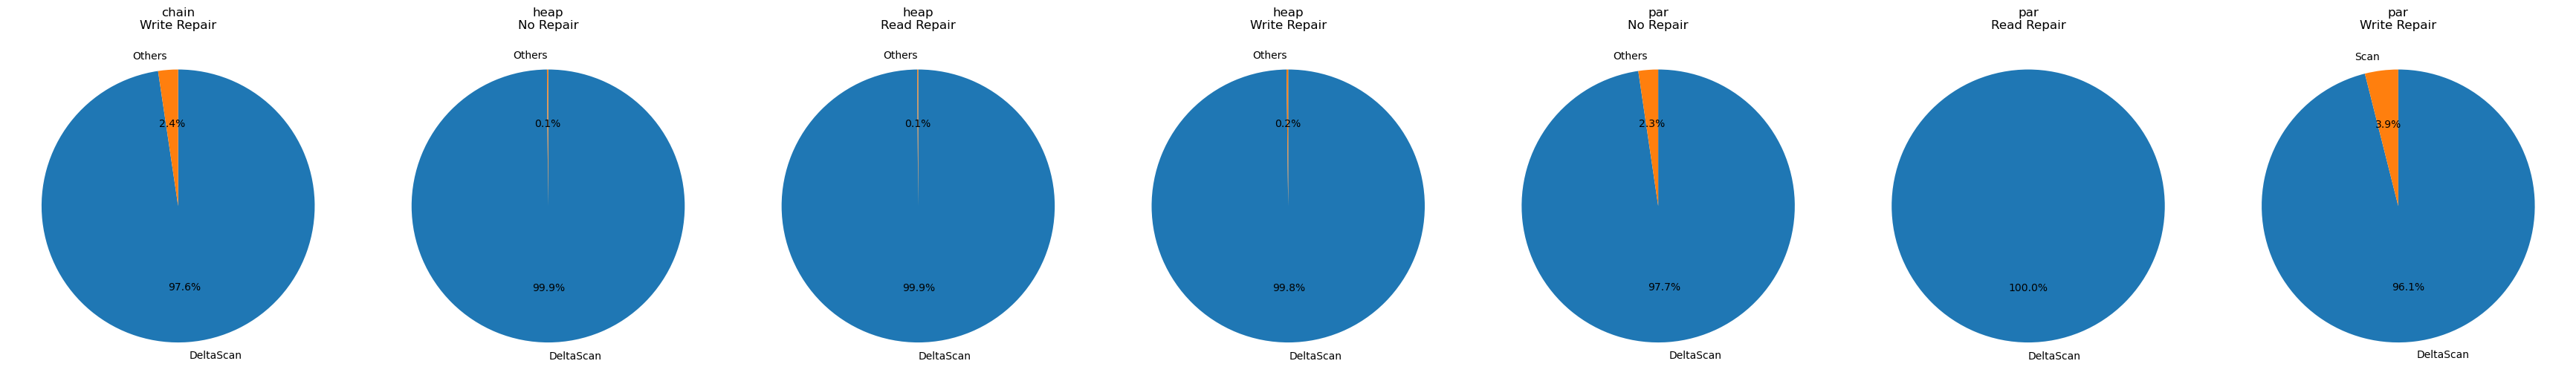

In [1]:
import subprocess
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re

# ----------------------------------------
# Build the Rust binary
# ----------------------------------------
print("=== Building Rust binary in release mode ===")
build_cmd = ["cargo", "build", "--release", "--bin", "htap_wkld"]
result = subprocess.run(build_cmd, capture_output=True, text=True)
if result.returncode != 0:
    print("[ERROR] cargo build failed.\n", result.stderr)
    raise SystemExit(1)
print("Cargo build completed successfully.\n")


BASE_ARGS = [
    "--txn-count", "40",  
    "--update-ratio", "0.005",
    "--warehouse-count", "35" # linear to base table size
]
REPEAT=1
BIN = Path("../../../target/release/htap_wkld")
TABLE_TYPES = ["naive", "heap", "par", "chain"] #, "par", "chain"
REUSE_CONFIGS = ["3", "6", "10", "14"] # (delta_count)

from bench_script_functions import run_and_collect
TRANSACTIONAL_TX_TYPE = ['InitLoad', 'Update']
ANALYTICAL_TX_TYPE = ['Probe', 'Scan', 'DeltaScan']

def get_avg(df):
    # display(df)
    table_types = sorted(df['table_type'].unique())
    repair_types = ["No Repair", "Read Repair", "Write Repair"]
    tx_type_groups = ["DeltaScan"]
    groups = []
    for table_type in table_types:
        if table_type in ['naive', 'chain']:
            groups.append((table_type, 'Write Repair'))
        else:
            for repair_type in repair_types:
                groups.append((table_type, repair_type))
    
    durations = []
    for i, (table_type, repair_type) in enumerate(groups):
        if table_type in ["chain", "naive"] and repair_type != "Write Repair":
            continue

        df_group = df[(df['table_type'] == table_type) & (df['repair_type'] == repair_type)]
        
        # DeltaScan only average
        # scan_vals = df_group['duration_ms'].values
        # avg_delta_scan = scan_vals.sum()
        # display(df_group)
        scan_vals = df_group['duration_ms'].sum()
        durations.append((table_type, repair_type, scan_vals)) # table_type, repair_type, avg_duration

        # display(df_group)
    return durations

# get ratio over base_type
def get_ratio(avg, base_type, delta_scan_intensity):
    result = []
    ratio_col_name = f'speed_ratio_over_{base_type}'
    base = None
    for (table_type, repair_type, avg_dur) in avg:
        if table_type in [base_type]:
            base = avg_dur
    
    for (table_type, repair_type, avg_dur) in avg:
        if table_type not in [base_type]:
            result.append({"delta_scan_intensity": delta_scan_intensity, "table_type": table_type, "repair_type": repair_type, ratio_col_name: base/ avg_dur})

    df_res = pd.DataFrame(result)
    return df_res
df_ratio = pd.DataFrame()
df_list = []
update_count = 0
for delta_scan_intensity, delta_scan_count in enumerate(REUSE_CONFIGS):
    NEW_ARGS = BASE_ARGS.copy()
    NEW_ARGS += ["--delta-count", delta_scan_count]
    
    df = run_and_collect(BIN, TABLE_TYPES, NEW_ARGS, REPEAT)
    update_count = (
        df[df["tx_type"] == "Update"]
        .groupby(["table_type", "repair_type"])
        .size()
        .iloc[0]  # 只取一个，因为都一样
    )
    # Display the resulting DataFrame
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    pd.set_option('display.max_colwidth', None)
    result = df.groupby(["table_type", "repair_type", "tx_type"])["duration_ms"].sum().reset_index()
    df_avg = get_avg(result)
    # print(aa)
    ratio = get_ratio(df_avg, 'naive', delta_scan_intensity)
    df_ratio = pd.concat([df_ratio, ratio], ignore_index=True)
    # display(result)
    df_list.append(result)
assert(len(df_list) > 1)
df_first = df_list[0]
df_last = df_list[-1]
merged = pd.merge(
    df_first,
    df_last,
    on=["table_type", "repair_type", "tx_type"],
    how="inner",
    suffixes=("_first", "_last")
)

df_filtered = merged[~(
    (merged["table_type"].isin(["naive", "chain"]) & (merged["repair_type"] != "Write Repair")) | merged["table_type"] == "naive"
)]

merged = df_filtered

# 
merged["delta"] = merged["duration_ms_last"] - merged["duration_ms_first"]

# 
group_total = merged.groupby(["table_type", "repair_type"])["delta"].transform("sum")

# 
merged["pct_contribution"] = merged["delta"] / group_total * 100
display(merged)


df = df_ratio.sort_values(by="delta_scan_intensity")

# (table_type, repair_type) 
plt.figure(figsize=(8,6))
for (table, repair), group in df.groupby(["table_type", "repair_type"]):
    plt.plot(group["delta_scan_intensity"], group["speed_ratio_over_naive"], 
             marker='o', label=f"{table}-{repair}")

plt.xlabel("DeltaScan Intensity")
plt.ylabel("Speed Ratio over Naive")
plt.title("Speed Ratio vs DeltaScan Intensity")
plt.legend()
plt.grid(True)
plt.show()

def stack_bar_chart_for_contribution(df, min_pct=0.02):
    # create a new column combining table_type and repair_type for x labels
    df["group"] = df["table_type"] + "\n" + df["repair_type"]

    # pivot so that tx_type becomes columns, pct_contribution values are stacked
    pivot_df = df.pivot_table(
        index="group",
        columns="tx_type",
        values="pct_contribution",
        aggfunc="sum",
        fill_value=0
    )

    display(pivot_df)

    # plot stacked bar
    ax = pivot_df.plot(
        kind="bar",
        stacked=True,
        figsize=(10, 6)
    )
    
    # add labels and title
    plt.ylabel("Pct Contribution (%)")
    plt.xlabel("Table Type - Repair Type")
    plt.xticks(rotation=0)
    plt.title("Operation Contribution Percentage(%) on Speed Degradation(DeltaScan Intensity)")
    plt.legend(title="tx_type", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
############################################################################################################
    # create one subplot per group
    n_groups = len(pivot_df)
    fig, axes = plt.subplots(1, n_groups, figsize=(5 * n_groups, 5))

    # if only one group, axes is not iterable
    if n_groups == 1:
        axes = [axes]

    for ax, (group, row) in zip(axes, pivot_df.iterrows()):
        row = row[row > 0]
        row = row / row.sum()

        # merge tiny slices into "Others"
        small = row[row < min_pct]
        row = row[row >= min_pct]
        if len(small) > 0:
            row["Others"] = small.sum()
        
        # draw pie chart
        ax.pie(
            row.values,
            labels=row.index,
            autopct="%1.1f%%",
            startangle=90,
            counterclock=False
        )
        ax.set_title(group)

    plt.tight_layout()
    plt.show()

df_filtered1 = merged[~(
    (merged["table_type"].isin(["naive", "chain"]) & (merged["repair_type"] != "Write Repair"))
)]


df_filtered = df_filtered1[~(
    df_filtered1["table_type"].isin(["naive"])
)]


stack_bar_chart_for_contribution(df_filtered)
